# Optimizing Kanji Learning Order
### CS210: Data Management for Data Science | Pranav Kalingeri Rao
#### [Project Proposal](https://drive.google.com/file/d/1unaRAXME38FKyGPeOQT1W-_NfALw23Lc/view?usp=sharing) | [Github Repository](https://github.com/Pranav396/KanjiLearningOrder) | [Web Dashboard*](https://kanjilearningorder.streamlit.app/) | [Demonstration Video](https://youtu.be/Eldi2rSrQFg) | [Project Report](https://drive.google.com/file/d/1DfbAauvffSvfRvxWZtVvIElZNTRiUJ3R/view?usp=sharing)
\*Given that the *Web Dashboard* is somewhat outside the scope of this assignment, I used the assistance of Anthropic's Claude to help navigate Streamlit.

<hr>

### Data Sources
| Source | Description | License | Link |
|--------|-------------|---------|------|
| WaniKani API | Kanji levels and radical names. | © Tofugu LLC | [api.wanikani.com](docs.api.wanikani.com/20170710/) |
| davidluzgouveia/kanji-data | JLPT levels, stroke counts, and grade. | MIT | [GitHub](https://github.com/davidluzgouveia/kanji-data) |
| scriptin/kanji-frequency | Corpus frequency ranks. | CC BY 4.0 | [GitHub](https://github.com/scriptin/kanji-frequency) |
| KANJIDIC2 (EDRDG) | Explored but unused. | CC BY-SA 4.0 | [edrdg.org](https://www.edrdg.org) |

<hr>

In [2]:
import requests
import json
import math
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter
import sqlite3
import ipywidgets as widgets
from IPython.display import display, clear_output

<hr>

### Task 1: Data Collection & Database Setup

#### 1.1: Parse KANJIDIC2
First, let's read the data from the KANJIDIC2 XML file and load into a pandas DataFrame. This will allow us to examine fields and clean the data appropriately before saving to a database.

In [3]:
response = requests.get('https://raw.githubusercontent.com/Pranav396/KanjiLearningOrder/main/Data/kanjidic2.xml')
root = ET.fromstring(response.text)

In [4]:
ET.tostring(root.find('character'), encoding='unicode').split('\n')

['<character>',
 '<literal>亜</literal>',
 '<codepoint>',
 '<cp_value cp_type="ucs">4e9c</cp_value>',
 '<cp_value cp_type="jis208">1-16-01</cp_value>',
 '</codepoint>',
 '<radical>',
 '<rad_value rad_type="classical">7</rad_value>',
 '<rad_value rad_type="nelson_c">1</rad_value>',
 '</radical>',
 '<misc>',
 '<grade>8</grade>',
 '<stroke_count>7</stroke_count>',
 '<variant var_type="jis208">1-48-19</variant>',
 '<freq>1509</freq>',
 '<jlpt>1</jlpt>',
 '</misc>',
 '<dic_number>',
 '<dic_ref dr_type="nelson_c">43</dic_ref>',
 '<dic_ref dr_type="nelson_n">81</dic_ref>',
 '<dic_ref dr_type="halpern_njecd">3540</dic_ref>',
 '<dic_ref dr_type="halpern_kkd">4354</dic_ref>',
 '<dic_ref dr_type="halpern_kkld">2204</dic_ref>',
 '<dic_ref dr_type="halpern_kkld_2ed">2966</dic_ref>',
 '<dic_ref dr_type="heisig">1809</dic_ref>',
 '<dic_ref dr_type="heisig6">1950</dic_ref>',
 '<dic_ref dr_type="gakken">1331</dic_ref>',
 '<dic_ref dr_type="oneill_names">525</dic_ref>',
 '<dic_ref dr_type="oneill_kk">178

In [5]:
records = []

for character in root.findall('character'):
    record = {}
    record['literal'] = character.findtext('literal')
    record['unicode'] = character.findtext('codepoint/cp_value')
    record['strokes'] = character.findtext('misc/stroke_count')
    record['frequency'] = character.findtext('misc/freq')
    record['jlpt'] = character.findtext('misc/jlpt')
    record['radical'] = character.findtext('radical/rad_value')
    records.append(record)

kd = pd.DataFrame(records)

In [6]:
kd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13108 entries, 0 to 13107
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   literal    13108 non-null  object
 1   unicode    13108 non-null  object
 2   strokes    13108 non-null  object
 3   frequency  2501 non-null   object
 4   jlpt       2230 non-null   object
 5   radical    13108 non-null  object
dtypes: object(6)
memory usage: 614.6+ KB


<span style="color: red;">Note: Despite parsing and loading KANJIDIC2 into a DataFrame, I later found another source of data that was more specific and updated to meet the needs of this project. While this data is not being used for this project, learning to parse an XML file was a valuable skill that I picked up in the process.</span>

#### 1.2: Load Jouyou Characters
The term *jouyou* (常用) refers to the 〜2136 common-use essential characters that Japanese students are taught by the time they finish middle school.

In [7]:
response = requests.get('https://raw.githubusercontent.com/Pranav396/KanjiLearningOrder/main/Data/jouyou.json')
jouyou = response.json()
jk = pd.DataFrame.from_dict(jouyou, orient='index') # jk stands for 'jouyou kanji'.

In [8]:
jk.index.name = 'character'
jk.reset_index(inplace=True)

In [9]:
jk.head()

,character,strokes,grade,freq,jlpt_old,jlpt_new,meanings,readings_on,readings_kun,wk_level,wk_meanings,wk_readings_on,wk_readings_kun,wk_radicals
0,一,1,1,2.0,4.0,5.0,"[One, One Radical (no.1)]","[いち, いつ]","[ひと-, ひと.つ]",1.0,[One],"[いち, いつ]",[!ひと],[Ground]
1,二,2,1,9.0,4.0,5.0,"[Two, Two Radical (no. 7)]","[に, じ]","[ふた, ふた.つ, ふたたび]",1.0,[Two],[に],[!ふた],[Two]
2,九,2,1,55.0,4.0,5.0,[Nine],"[きゅう, く]","[ここの, ここの.つ]",1.0,[Nine],"[く, きゅう]",[!ここの],[Nine]
3,七,2,1,115.0,4.0,5.0,[Seven],[しち],"[なな, なな.つ, なの]",1.0,[Seven],[しち],"[!なな, !なの]",[Seven]
4,人,2,1,5.0,4.0,5.0,[Person],"[じん, にん]","[ひと, -り, -と]",1.0,[Person],"[にん, じん]","[!ひと, !と]",[Person]


I will explain the meanings of each of the fields after cleaning up the DataFrame a bit more in a later section.

#### 1.3: Load WaniKani Characters
WaniKani is an app for English speakers that teaches kanji through radicals, smaller components of kanji, and spaced repetition. It gamifies the learning process by assigning levels (1-60) to the kanji they cover. This could be an interesting point of comparison. Please note that we do not use the fields from `jk` for this section because WaniKani undergoes regular updates, and those fields are rather dated.

In [10]:
response = requests.get('https://raw.githubusercontent.com/Pranav396/KanjiLearningOrder/main/Data/wk_kanji.json')
wanikani = response.json()

The WaniKani data was obtained through the site's official API. This notebook calls from the JSON stored in the Github for this project, but the original script can also be found in the repository.

In [11]:
wk = pd.DataFrame(wanikani)

In [12]:
wk.head()

,character,wk_level,radical_ids,radical_names
0,一,1,[1],[Ground]
1,二,1,[7],[Two]
2,九,1,[11],[Nine]
3,七,1,[4],[Seven]
4,人,1,[9],[Person]


#### 1.4: Load Frequency Data
Given that the frequency data from `KANJIDIC` only considers newspapers, it would be more prudent to include other sources. As such, we will be using Dmitry Schpika's work which compiles across Japanese WikiNews, Wikipedia articles, and books from the Aozora Bunko digital library.

In [13]:
aozora = pd.read_csv('https://raw.githubusercontent.com/Pranav396/KanjiLearningOrder/main/Data/aozora.csv')
aozora.head()

,rank,code_point_hex,char,char_count
0,0,0,all,67805014
1,1,4eba,人,1043809
2,2,4e00,一,969014
3,3,898b,見,644840
4,4,51fa,出,588684


In [14]:
wiki = pd.read_csv('https://raw.githubusercontent.com/Pranav396/KanjiLearningOrder/main/Data/wikipedia.csv')
wiki.head()

,rank,code_point_hex,char,char_count
0,0,0,all,59301009
1,1,5e74,年,1688601
2,2,65e5,日,910717
3,3,6708,月,784226
4,4,5927,大,550182


In [15]:
news = pd.read_csv('https://raw.githubusercontent.com/Pranav396/KanjiLearningOrder/main/Data/news.csv')
news.head()

,rank,code_point_hex,char,char_count
0,0,0,all,1117683
1,1,65e5,日,41749
2,2,5e74,年,24412
3,3,6708,月,22290
4,4,65b0,新,15957


<hr>

### Task 2: Data Integration & Cleaning

#### 2.1: Clean the `jk` DataFrame
Given that we will be merging multiple datasets later, we can drop the fields that we do not need from the `jk` DataFrame. We can also change up the datatypes to more suitable ones.

In [16]:
jk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   character        2136 non-null   object 
 1   strokes          2136 non-null   int64  
 2   grade            2136 non-null   int64  
 3   freq             2039 non-null   float64
 4   jlpt_old         1979 non-null   float64
 5   jlpt_new         1964 non-null   float64
 6   meanings         2136 non-null   object 
 7   readings_on      2136 non-null   object 
 8   readings_kun     2136 non-null   object 
 9   wk_level         1963 non-null   float64
 10  wk_meanings      1963 non-null   object 
 11  wk_readings_on   1963 non-null   object 
 12  wk_readings_kun  1963 non-null   object 
 13  wk_radicals      1963 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 233.8+ KB


From the above fields, the ones that we will keep are as follows:
* character: Stores the actual character.
* strokes: The number of strokes. This is an indicator of the complexity of the character.
* grade: The school grade that the character is taught in. It is a point of comparison for later.
* freq: The frequency assigned from the news sources. This could also be a point of comparison.
* jlpt_new: The Japanese Language Proficiency Test ranking assigned to each character. The ranking goes from 5 being the easiest to 1 being the hardest.

From the above fields, the ones that we will be dropping are as follows:
* jlpt_old: We do not require the older rankings that were phased out.
* meanings: We are not interested in the actual meanings.
* readings_on: Once again, we are not interested in the Chinese readings.
* readings_kun: Similarly, we do not work with the Japanese readings either.
* wk_* Fields: These fields will later be brought back on through the WaniKani dataset.

In [17]:
jk = jk.drop(['jlpt_old', 'meanings', 'readings_on', 'readings_kun', 'wk_level',
              'wk_meanings', 'wk_readings_on', 'wk_readings_kun', 'wk_radicals'], axis=1)

In [18]:
for column in jk.columns:
    print(f"{column}: {jk[column].min()} - {jk[column].max()}")

character: 一 - 齢
strokes: 1 - 29
grade: 1 - 8
freq: 1.0 - 2495.0
jlpt_new: 1.0 - 5.0


In [19]:
jk['strokes'] = pd.to_numeric(jk['strokes'], downcast='unsigned', errors='raise')
jk['grade'] = pd.to_numeric(jk['grade'], downcast='unsigned', errors='raise')
jk['freq'] = pd.to_numeric(jk['freq'], errors='raise').astype('UInt16')
jk['jlpt_new'] = pd.to_numeric(jk['jlpt_new'], errors='raise').astype('UInt8')

We use `UInt16` and `UInt8` to preserve the `None` values.

Next, let's assign a sentinel JLPT value for those characters that do not have one. We will use `0` with these characters not being considered for the comparisons later on.

In [20]:
jk['jlpt_new'] = jk['jlpt_new'].fillna(0).astype('UInt8')

For the missing `frequency` values, let's impute the value based on the medians of characters which are taught in the same grade with the same number of strokes.

In [21]:
def fill_freq(group):
    median = group.median()
    if pd.isna(median):
        return group
    return group.fillna(math.floor(median))

jk['freq'] = jk.groupby(['strokes', 'grade'])['freq'].transform(fill_freq)

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [22]:
jk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   character  2136 non-null   object
 1   strokes    2136 non-null   uint8 
 2   grade      2136 non-null   uint8 
 3   freq       2135 non-null   UInt16
 4   jlpt_new   2136 non-null   UInt8 
dtypes: UInt16(1), UInt8(1), object(1), uint8(2)
memory usage: 31.4+ KB


Given that there are still missing frequencies, we can fall back on imputations that are less specific.

In [23]:
jk['freq'] = jk.groupby('strokes')['freq'].transform(fill_freq)
jk['freq'] = jk['freq'].fillna(math.floor(jk['freq'].median()))

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [24]:
jk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   character  2136 non-null   object
 1   strokes    2136 non-null   uint8 
 2   grade      2136 non-null   uint8 
 3   freq       2136 non-null   UInt16
 4   jlpt_new   2136 non-null   UInt8 
dtypes: UInt16(1), UInt8(1), object(1), uint8(2)
memory usage: 31.4+ KB


#### 2.2: Clean the `wk` DataFrame
Given that we will be merging multiple datasets later, we can change the datatypes to more suitable ones.

In [25]:
wk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2099 entries, 0 to 2098
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   character      2099 non-null   object
 1   wk_level       2099 non-null   int64 
 2   radical_ids    2099 non-null   object
 3   radical_names  2099 non-null   object
dtypes: int64(1), object(3)
memory usage: 65.7+ KB


In [26]:
for column in wk.columns:
    print(f"{column}: {wk[column].min()} - {wk[column].max()}")

character: 々 - 龍
wk_level: 1 - 60
radical_ids: [1] - [9452, 8770]
radical_names: ['Ability', 'Boil'] - ['Yurt', 'Towel']


In [27]:
wk['wk_level'] = pd.to_numeric(wk['wk_level'], downcast='unsigned', errors='raise')

In [28]:
wk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2099 entries, 0 to 2098
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   character      2099 non-null   object
 1   wk_level       2099 non-null   uint8 
 2   radical_ids    2099 non-null   object
 3   radical_names  2099 non-null   object
dtypes: object(3), uint8(1)
memory usage: 51.4+ KB


#### 2.3: Clean the Frequency DataFrames
Given that we will be merging multiple datasets later, we can change the datatypes to more suitable ones.

##### 2.3.1: `aozora`

In [29]:
aozora.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7916 entries, 0 to 7915
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rank            7916 non-null   int64 
 1   code_point_hex  7916 non-null   object
 2   char            7916 non-null   object
 3   char_count      7916 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 247.5+ KB


In [30]:
for column in aozora.columns:
    print(f"{column}: {aozora[column].min()} - {aozora[column].max()}")

rank: 0 - 3440
code_point_hex: 0 - fa1f
char: all - 𠹭
char_count: 1 - 67805014


In [31]:
aozora['rank'] = pd.to_numeric(aozora['rank'], downcast='unsigned', errors='raise')

In [32]:
aozora = aozora.drop(0)

In [33]:
aozora.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7915 entries, 1 to 7915
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rank            7915 non-null   uint16
 1   code_point_hex  7915 non-null   object
 2   char            7915 non-null   object
 3   char_count      7915 non-null   int64 
dtypes: int64(1), object(2), uint16(1)
memory usage: 201.1+ KB


##### 2.3.2: `wiki`

In [34]:
wiki.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8485 entries, 0 to 8484
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rank            8485 non-null   int64 
 1   code_point_hex  8485 non-null   object
 2   char            8485 non-null   object
 3   char_count      8485 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 265.3+ KB


In [35]:
for column in wiki.columns:
    print(f"{column}: {wiki[column].min()} - {wiki[column].max()}")

rank: 0 - 2734
code_point_hex: 0 - fa24
char: all - 𱁬
char_count: 1 - 59301009


In [36]:
wiki['rank'] = pd.to_numeric(wiki['rank'], downcast='unsigned', errors='raise')

In [37]:
wiki = wiki.drop(0)

In [38]:
wiki.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8484 entries, 1 to 8484
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rank            8484 non-null   uint16
 1   code_point_hex  8484 non-null   object
 2   char            8484 non-null   object
 3   char_count      8484 non-null   int64 
dtypes: int64(1), object(2), uint16(1)
memory usage: 215.5+ KB


##### 2.3.3: `news`

In [39]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2941 entries, 0 to 2940
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rank            2941 non-null   int64 
 1   code_point_hex  2941 non-null   object
 2   char            2941 non-null   object
 3   char_count      2941 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 92.0+ KB


In [40]:
for column in news.columns:
    print(f"{column}: {news[column].min()} - {news[column].max()}")

rank: 0 - 830
code_point_hex: 0 - fa11
char: all - 﨑
char_count: 1 - 1117683


In [41]:
news['rank'] = pd.to_numeric(news['rank'], downcast='unsigned', errors='raise')

In [42]:
news = news.drop(0)

In [43]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 1 to 2940
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rank            2940 non-null   uint16
 1   code_point_hex  2940 non-null   object
 2   char            2940 non-null   object
 3   char_count      2940 non-null   int64 
dtypes: int64(1), object(2), uint16(1)
memory usage: 74.8+ KB


<hr>

### Task 3: Merging DataFrames

While the `character` fields itself is a good field to merge on, adding the `unicode` field as a basis for our merges seems more standardized.

#### 3.1: Add the `unicode` Fields to `wk` and `jk`

In [44]:
jk['unicode'] = jk['character'].apply(ord).apply(hex).str[2:]
jk.head()

,character,strokes,grade,freq,jlpt_new,unicode
0,一,1,1,2,5,4e00
1,二,2,1,9,5,4e8c
2,九,2,1,55,5,4e5d
3,七,2,1,115,5,4e03
4,人,2,1,5,5,4eba


In [45]:
wk['unicode'] = wk['character'].apply(ord).apply(hex).str[2:]
wk.head()

,character,wk_level,radical_ids,radical_names,unicode
0,一,1,[1],[Ground],4e00
1,二,1,[7],[Two],4e8c
2,九,1,[11],[Nine],4e5d
3,七,1,[4],[Seven],4e03
4,人,1,[9],[Person],4eba


#### 3.2: Rename Columns in `news`, `aozora`, and `wiki`

We do this renaming such that we have an easier time merging before we add more features.

In [46]:
aozora = aozora.rename(columns={'code_point_hex':'unicode', 'rank':'a_rank'})
wiki = wiki.rename(columns={'code_point_hex':'unicode', 'rank':'w_rank'})
news = news.rename(columns={'code_point_hex':'unicode', 'rank':'n_rank'})

#### 3.3: Merge `news`, `aozora`, and `wiki`

In [47]:
news.shape

(2940, 4)

In [48]:
wiki.shape

(8484, 4)

In [49]:
aozora.shape

(7915, 4)

Given that `news` has the smallest set of characters, let us use this as the main DataFrame to merge to.

In [50]:
frequencies = news
aozora = aozora.drop(['char', 'char_count'], axis=1)
wiki = wiki.drop(['char', 'char_count'], axis=1)
news = news.drop('char_count', axis=1)

In [51]:
frequencies = pd.merge(news, wiki, on='unicode', how='left')

In [52]:
frequencies = pd.merge(frequencies, aozora, on='unicode', how='left')

In [53]:
# Rearranging the columns.
frequencies = frequencies[['unicode', 'char', 'n_rank', 'w_rank', 'a_rank']]
frequencies.head()

,unicode,char,n_rank,w_rank,a_rank
0,65e5,日,1,2.0,8.0
1,5e74,年,2,1.0,38.0
2,6708,月,3,3.0,77.0
3,65b0,新,4,48.0,115.0
4,805e,聞,5,530.0,69.0


#### 3.4: Merge `frequencies` with `jk`

In [54]:
frequencies = frequencies.drop('char', axis=1)

In [55]:
jk = pd.merge(jk, frequencies, on='unicode', how='left')

In [56]:
jk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   character  2136 non-null   object 
 1   strokes    2136 non-null   uint8  
 2   grade      2136 non-null   uint8  
 3   freq       2136 non-null   UInt16 
 4   jlpt_new   2136 non-null   UInt8  
 5   unicode    2136 non-null   object 
 6   n_rank     2073 non-null   float64
 7   w_rank     2073 non-null   float64
 8   a_rank     2073 non-null   float64
dtypes: UInt16(1), UInt8(1), float64(3), object(2), uint8(2)
memory usage: 98.2+ KB


#### 3.5: Merge `wk` with `jk`

In [57]:
wk = wk.drop('character', axis=1)

In [58]:
jk = pd.merge(jk, wk, on='unicode', how='left')

In [59]:
jk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   character      2136 non-null   object 
 1   strokes        2136 non-null   uint8  
 2   grade          2136 non-null   uint8  
 3   freq           2136 non-null   UInt16 
 4   jlpt_new       2136 non-null   UInt8  
 5   unicode        2136 non-null   object 
 6   n_rank         2073 non-null   float64
 7   w_rank         2073 non-null   float64
 8   a_rank         2073 non-null   float64
 9   wk_level       2002 non-null   float64
 10  radical_ids    2002 non-null   object 
 11  radical_names  2002 non-null   object 
dtypes: UInt16(1), UInt8(1), float64(4), object(4), uint8(2)
memory usage: 148.2+ KB


#### 3.6: Optimize `jk` Memory

In [60]:
for column in jk.columns[:-2]:
    print(f"{column}: {jk[column].min()} - {jk[column].max()}")

character: 一 - 齢
strokes: 1 - 29
grade: 1 - 8
freq: 1 - 2495
jlpt_new: 0 - 5
unicode: 4e00 - 9f62
n_rank: 1.0 - 830.0
w_rank: 1.0 - 2650.0
a_rank: 1.0 - 3307.0
wk_level: 1.0 - 60.0


In [61]:
jk['wk_level'] = pd.to_numeric(jk['wk_level'], errors='raise').astype('UInt16')
jk['n_rank'] = pd.to_numeric(jk['n_rank'], errors='raise').astype('UInt16')
jk['w_rank'] = pd.to_numeric(jk['w_rank'], errors='raise').astype('UInt16')
jk['a_rank'] = pd.to_numeric(jk['a_rank'], errors='raise').astype('UInt16')

In [62]:
jk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   character      2136 non-null   object
 1   strokes        2136 non-null   uint8 
 2   grade          2136 non-null   uint8 
 3   freq           2136 non-null   UInt16
 4   jlpt_new       2136 non-null   UInt8 
 5   unicode        2136 non-null   object
 6   n_rank         2073 non-null   UInt16
 7   w_rank         2073 non-null   UInt16
 8   a_rank         2073 non-null   UInt16
 9   wk_level       2002 non-null   UInt16
 10  radical_ids    2002 non-null   object
 11  radical_names  2002 non-null   object
dtypes: UInt16(5), UInt8(1), object(4), uint8(2)
memory usage: 106.5+ KB


#### 3.7: Impute `rank` Values

Since these values will be directly used in our analysis, it is crucial that they are estimated. We will be using the same sort of imputation based on the medians of similar characters that we used earlier.

In [63]:
jk['n_rank'] = jk.groupby(['strokes', 'grade'])['n_rank'].transform(fill_freq)

In [64]:
jk['w_rank'] = jk.groupby(['strokes', 'grade'])['w_rank'].transform(fill_freq)

In [65]:
jk['a_rank'] = jk.groupby(['strokes', 'grade'])['a_rank'].transform(fill_freq)

In [66]:
jk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   character      2136 non-null   object
 1   strokes        2136 non-null   uint8 
 2   grade          2136 non-null   uint8 
 3   freq           2136 non-null   UInt16
 4   jlpt_new       2136 non-null   UInt8 
 5   unicode        2136 non-null   object
 6   n_rank         2136 non-null   UInt16
 7   w_rank         2136 non-null   UInt16
 8   a_rank         2136 non-null   UInt16
 9   wk_level       2002 non-null   UInt16
 10  radical_ids    2002 non-null   object
 11  radical_names  2002 non-null   object
dtypes: UInt16(5), UInt8(1), object(4), uint8(2)
memory usage: 106.5+ KB


Given that there are no null values left unhandled, we do not need to fall back on broader means of imputation.

<hr>

### Task 4: Feature Engineering

In this section, we will compute the main metrics that we will be using to cluster and group the data in the next section.

#### 4.1: Compute `avg_rank`

##### 4.1.1: Normalize Ranks

From the ranges that we saw earlier, we know that the ranks have quite the variation depending on the media. To account for these, we must first normalize them to be between 0 and 1 (inclusive). We then also invert their scores by subtracting from 1. We do so to make sure that low rank, which implies high utility, also has a high rank.

In [67]:
scaler = MinMaxScaler()
jk[['norm_n', 'norm_w', 'norm_a']] = scaler.fit_transform(jk[['n_rank', 'w_rank', 'a_rank']])

In [68]:
jk['inv_n'] = 1 - jk['norm_n']
jk['inv_w'] = 1 - jk['norm_w']
jk['inv_a'] = 1 - jk['norm_a']

##### 4.1.2: Compute Average

We take the average of the frequencies across the three sources to gain a more well-rounded metric for frequency. This will yield our metric for utility, i.e., how much utility can learning this character yield when actually engaging with media.

In [69]:
jk['util_score'] = (jk['inv_n'] + jk['inv_w'] + jk['inv_a'])/3

In [70]:
jk.head()

,character,strokes,grade,freq,jlpt_new,unicode,n_rank,w_rank,a_rank,wk_level,radical_ids,radical_names,norm_n,norm_w,norm_a,inv_n,inv_w,inv_a,util_score
0,一,1,1,2,5,4e00,41,9,2,1,[1],[Ground],0.048251,0.003020,0.000302,0.951749,0.996980,0.999698,0.982809
1,二,2,1,9,5,4e8c,391,163,17,1,[7],[Two],0.470446,0.061155,0.004840,0.529554,0.938845,0.995160,0.821186
2,九,2,1,55,5,4e5d,404,642,228,1,[11],[Nine],0.486128,0.241978,0.068663,0.513872,0.758022,0.931337,0.734410
3,七,2,1,115,5,4e03,759,777,161,1,[4],[Seven],0.914355,0.292941,0.048397,0.085645,0.707059,0.951603,0.581436
4,人,2,1,5,5,4eba,7,7,1,1,[9],[Person],0.007238,0.002265,0.000000,0.992762,0.997735,1.000000,0.996832


#### 4.2: Normalize and Invert `strokes`

In [71]:
# Normalizing strokes.
jk['norm_strokes'] = scaler.fit_transform(jk[['strokes']])

We then invert `norm_strokes` as the lower the number of strokes, the higher the `simp_score`.

In [72]:
# Inverting strokes.
jk['simp_score'] = 1 - jk['norm_strokes']

This metric is our indicator of complexity (or simplicity as we have labeled in this case). The `simp_score` indicates the difficulty of memorizing or recognizing the character.

In [73]:
jk.head()

,character,strokes,grade,freq,jlpt_new,unicode,n_rank,w_rank,a_rank,wk_level,...,radical_names,norm_n,norm_w,norm_a,inv_n,inv_w,inv_a,util_score,norm_strokes,simp_score
0,一,1,1,2,5,4e00,41,9,2,1,...,[Ground],0.048251,0.003020,0.000302,0.951749,0.996980,0.999698,0.982809,0.000000,1.000000
1,二,2,1,9,5,4e8c,391,163,17,1,...,[Two],0.470446,0.061155,0.004840,0.529554,0.938845,0.995160,0.821186,0.035714,0.964286
2,九,2,1,55,5,4e5d,404,642,228,1,...,[Nine],0.486128,0.241978,0.068663,0.513872,0.758022,0.931337,0.734410,0.035714,0.964286
3,七,2,1,115,5,4e03,759,777,161,1,...,[Seven],0.914355,0.292941,0.048397,0.085645,0.707059,0.951603,0.581436,0.035714,0.964286
4,人,2,1,5,5,4eba,7,7,1,1,...,[Person],0.007238,0.002265,0.000000,0.992762,0.997735,1.000000,0.996832,0.035714,0.964286


#### 4.3: Compute `learnability`

The `learnability` metric combines our previously computed `util_score` and `simp_score`, treating both as equally important. This means that this score reflects how easy a character is to recognize as well as the utility gained from recognizing it.

In [74]:
jk['learnability'] = (0.5 * jk['util_score']) + (0.5 * jk['simp_score'])

In [75]:
jk.head()

,character,strokes,grade,freq,jlpt_new,unicode,n_rank,w_rank,a_rank,wk_level,...,norm_n,norm_w,norm_a,inv_n,inv_w,inv_a,util_score,norm_strokes,simp_score,learnability
0,一,1,1,2,5,4e00,41,9,2,1,...,0.048251,0.003020,0.000302,0.951749,0.996980,0.999698,0.982809,0.000000,1.000000,0.991404
1,二,2,1,9,5,4e8c,391,163,17,1,...,0.470446,0.061155,0.004840,0.529554,0.938845,0.995160,0.821186,0.035714,0.964286,0.892736
2,九,2,1,55,5,4e5d,404,642,228,1,...,0.486128,0.241978,0.068663,0.513872,0.758022,0.931337,0.734410,0.035714,0.964286,0.849348
3,七,2,1,115,5,4e03,759,777,161,1,...,0.914355,0.292941,0.048397,0.085645,0.707059,0.951603,0.581436,0.035714,0.964286,0.772861
4,人,2,1,5,5,4eba,7,7,1,1,...,0.007238,0.002265,0.000000,0.992762,0.997735,1.000000,0.996832,0.035714,0.964286,0.980559


#### 4.4: Exploring `learnability`

##### 4.4.1: Top Twenty Characters

In [76]:
jk.sort_values('learnability', ascending=False).iloc[:20, [0, 18, 20, 21]]

,character,util_score,simp_score,learnability
0,一,0.982809,1.000000,0.991404
4,人,0.996832,0.964286,0.980559
13,大,0.996304,0.928571,0.962438
5,入,0.959716,0.964286,0.962001
10,上,0.988584,0.928571,0.958578
22,子,0.968707,0.928571,0.948639
36,日,0.999168,0.892857,0.946013
15,山,0.958615,0.928571,0.943593
29,中,0.992080,0.892857,0.942468
37,月,0.991281,0.892857,0.942069


##### 4.4.2: Bottom Twenty Characters

In [77]:
jk.sort_values('learnability').iloc[:20, [0, 18, 20, 21]]

,character,util_score,simp_score,learnability
1636,鬱,0.249058,1.110223e-16,0.124529
2021,璽,0.014001,3.571429e-01,0.185572
2092,繭,0.064948,3.928571e-01,0.228903
2133,錮,0.010315,4.642857e-01,0.237301
1849,醸,0.169516,3.214286e-01,0.245472
2122,璧,0.107841,3.928571e-01,0.250349
1732,騰,0.195041,3.214286e-01,0.258235
1954,矯,0.095386,4.285714e-01,0.261978
1641,諮,0.068410,4.642857e-01,0.266348
1984,嚇,0.107082,4.285714e-01,0.267827


##### 4.4.3: Distribution of Learnability Scores

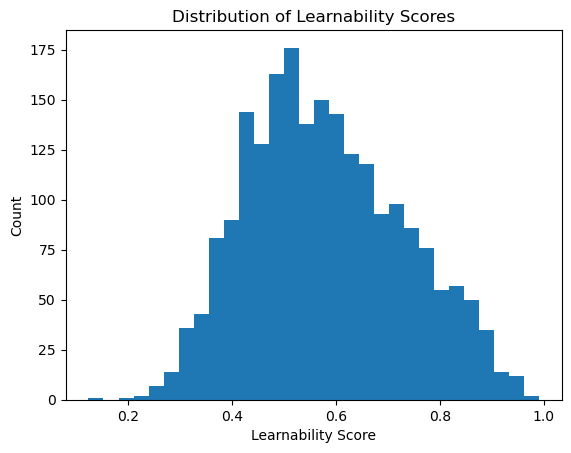

In [78]:
plt.hist(jk['learnability'], bins=30)
plt.xlabel('Learnability Score')
plt.ylabel('Count')
plt.title('Distribution of Learnability Scores')
plt.show()

Seeing a rather *normal* distribution is quite the pleasant surprise.

##### 4.4.4: Scatterplot Analysis

Since we used the sentinel value of 0 for the JLPT levels that we imputed, we won't be considering them for the following discussion.

In [79]:
jk_jlpt = jk[jk['jlpt_new'] != 0]

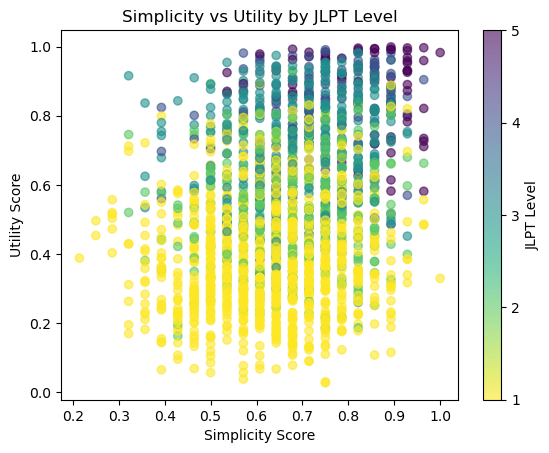

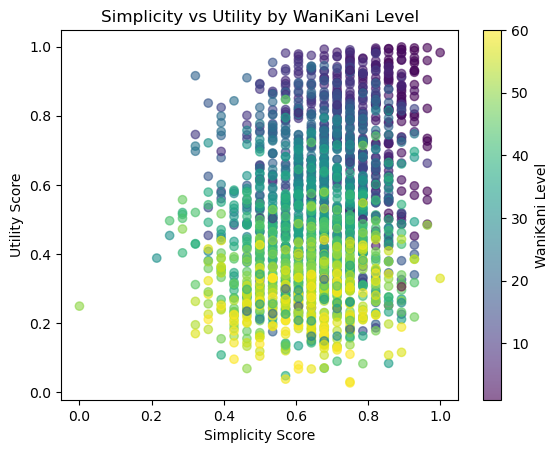

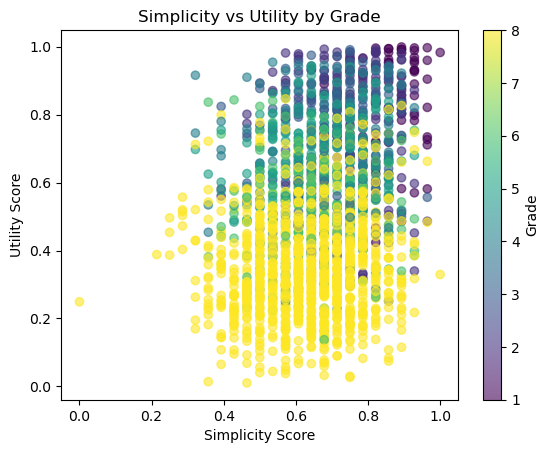

In [80]:
for col, title in [('jlpt_new', 'JLPT Level'), ('wk_level', 'WaniKani Level'), ('grade', 'Grade')]:
    data = jk_jlpt if col == 'jlpt_new' else jk
    cmap = 'viridis_r' if col == 'jlpt_new' else 'viridis'
    plt.scatter(data['simp_score'], data['util_score'], c=data[col], cmap=cmap, alpha=0.6)
    cbar = plt.colorbar(label=title)
    if col == 'jlpt_new':
        cbar.set_ticks(sorted(jk_jlpt['jlpt_new'].unique()))
    plt.xlabel('Simplicity Score')
    plt.ylabel('Utility Score')
    plt.title(f'Simplicity vs Utility by {title}')
    plt.show()

We see a similar pattern across all the plots where the grade/level increases in correspondence with lower utility and simplicity. That is to say, the tougher characters are taught later on.

##### 4.4.5: Average `learnability` Metrics

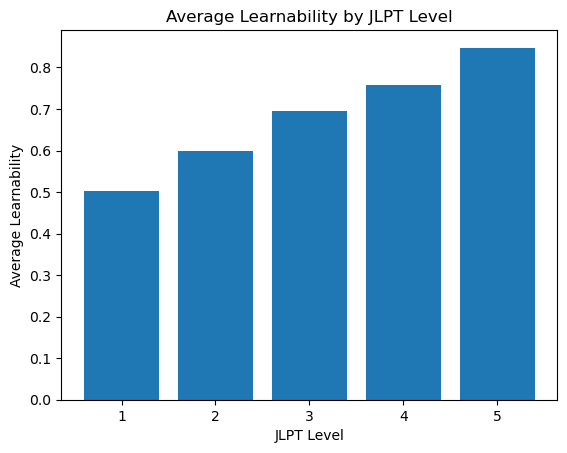

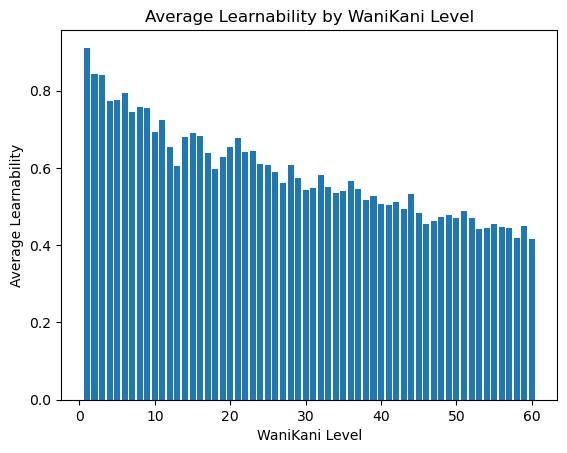

In [81]:
for col, title in [('jlpt_new', 'JLPT Level'), ('wk_level', 'WaniKani Level')]:
    data = jk_jlpt if col == 'jlpt_new' else jk
    avg = data.groupby(col)['learnability'].mean().sort_index()
    plt.bar(avg.index, avg.values)
    plt.xlabel(title)
    plt.ylabel('Average Learnability')
    plt.title(f'Average Learnability by {title}')
    plt.show()

Even here, we observe that the learnability generally goes down as the difficulty increases in terms of WaniKani or JLPT level.

<hr>

### Task 5: Clustering

#### 5.1: Deciding the Dimensions

The dimensions for our clustering will be `simp_score` and `util_score`. We will have clusters of characters that have similar simplicity and utility. We can then decide on the order of the clusters for the best learning experience.

In [82]:
X = jk[['simp_score', 'util_score']].values

#### 5.2: Deciding *k*

Given that we aren't exactly aware of how many clusters we want, we will explore from a range of potential clusters. This process is akin to finding out when the loss function plateaus. Our methodology is called the *[elbow method](https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/)* where we plot inertia (the sum of squared distances to the centers) against *k* (akin to loss). We then look for the point where the intertia stops dropping sharply (i.e., plateaus).

Note: We consistently stick with `random_state=42` for the sake of reproducibility.

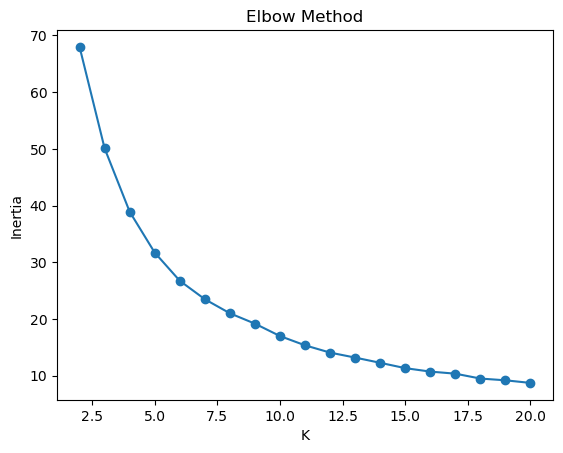

In [83]:
inertias = []
K_range = range(2, 21)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

#### 5.3: Utilizing Silhouette Scores

While a pretty sharp elbow is vident around *k = 4* and *k = 6*, we can make sure to get a concrete answer by computing silhouette scores. Silhouette scores measure how similar a point is to its own cluster compared to other clusters. This score is normalized between -1 and 1, with a higher score being more suitable.

In [84]:
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    print(f'K = {k}: Silhouette = {silhouette_score(X, labels):.4f}')

K = 2: Silhouette = 0.4667
K = 3: Silhouette = 0.3619
K = 4: Silhouette = 0.3455
K = 5: Silhouette = 0.3422
K = 6: Silhouette = 0.3430
K = 7: Silhouette = 0.3303
K = 8: Silhouette = 0.3292
K = 9: Silhouette = 0.3258
K = 10: Silhouette = 0.3291
K = 11: Silhouette = 0.3356
K = 12: Silhouette = 0.3367
K = 13: Silhouette = 0.3403
K = 14: Silhouette = 0.3386
K = 15: Silhouette = 0.3347
K = 16: Silhouette = 0.3342
K = 17: Silhouette = 0.3231
K = 18: Silhouette = 0.3369
K = 19: Silhouette = 0.3309
K = 20: Silhouette = 0.3299


While having *2* clusters seems to have the highest silhouette score, in our context it does not offer much insight. Given that we have two dimensions, each taking on binary values, we could reasonably go with *4* clusters. Having *4* clusters also has one of the highest silhouette scores which does inspire confidence.

#### 5.4: Fitting the Model

In [85]:
K = 4
km = KMeans(n_clusters=K, random_state=42)
jk['cluster'] = km.fit_predict(X)

Now, moving on the descriptions of the centers.

As for the labelling of the centers, we will be following this pattern.
|                | util_score: High | util_score: Low  |
|----------------|------------------|------------------|
| **simp_score: High** | Easy & Common   | Easy & Rare      |
| **simp_score: Low**  | Hard & Common   | Hard & Rare      |

In [86]:
centers = pd.DataFrame(km.cluster_centers_, columns=['simp_score', 'util_score'])
print(centers)

   simp_score  util_score
0    0.632288    0.576764
1    0.743225    0.319989
2    0.758346    0.828042
3    0.518958    0.285893


Following the format detailed by the above table, we can assign the following labels to each of the clusters.

In [87]:
cluster_labels = {2: 'Easy & Common', 1: 'Easy & Rare', 
                  0: 'Hard & Common', 3: 'Hard & Rare'}
jk['cluster_label'] = jk['cluster'].map(cluster_labels)

In [88]:
jk.head()

,character,strokes,grade,freq,jlpt_new,unicode,n_rank,w_rank,a_rank,wk_level,...,norm_a,inv_n,inv_w,inv_a,util_score,norm_strokes,simp_score,learnability,cluster,cluster_label
0,一,1,1,2,5,4e00,41,9,2,1,...,0.000302,0.951749,0.996980,0.999698,0.982809,0.000000,1.000000,0.991404,2,Easy & Common
1,二,2,1,9,5,4e8c,391,163,17,1,...,0.004840,0.529554,0.938845,0.995160,0.821186,0.035714,0.964286,0.892736,2,Easy & Common
2,九,2,1,55,5,4e5d,404,642,228,1,...,0.068663,0.513872,0.758022,0.931337,0.734410,0.035714,0.964286,0.849348,2,Easy & Common
3,七,2,1,115,5,4e03,759,777,161,1,...,0.048397,0.085645,0.707059,0.951603,0.581436,0.035714,0.964286,0.772861,2,Easy & Common
4,人,2,1,5,5,4eba,7,7,1,1,...,0.000000,0.992762,0.997735,1.000000,0.996832,0.035714,0.964286,0.980559,2,Easy & Common


#### 5.5: Visualizations and Comparisons

##### 5.5.1: Comparing Against JLPT Levels

In [89]:
pd.crosstab(jk[jk['jlpt_new'] != 0]['cluster_label'], jk[jk['jlpt_new'] != 0]['jlpt_new'])

jlpt_new,1,2,3,4,5
cluster_label,,,,,
Easy & Common,32,55,185,121,76
Easy & Rare,357,85,22,5,0
Hard & Common,232,182,156,39,3
Hard & Rare,364,45,4,1,0


We see that once again, things get progressively harder as the JLPT gets more difficult.

##### 5.5.2: Average WaniKani Level Per Cluster

In [90]:
jk.groupby('cluster_label')['wk_level'].mean().sort_values()

cluster_label
Easy & Common    11.302521
Hard & Common    25.009756
Easy & Rare      40.705521
Hard & Rare      44.485782
Name: wk_level, dtype: Float64

From the results, we see that WaniKani emphasizes teaching common characters first. This aligns with WaniKani's choice of dealing with complexity through spaced repetition.

##### 5.5.3: Visualizing the Clusters

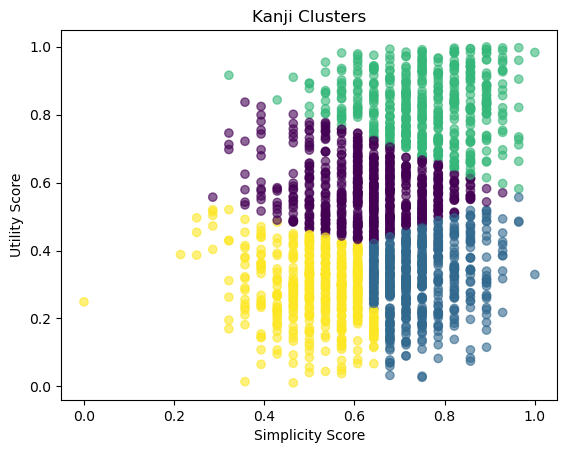

In [91]:
plt.scatter(jk['simp_score'], jk['util_score'], c=jk['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Simplicity Score')
plt.ylabel('Utility Score')
plt.title('Kanji Clusters')
plt.show()

#### 5.6: Radical Analysis

Radicals are the components that make up kanji characters. That is, many kanji characters are compounds of many radicals which contribute towards the character's reading and/or meaning.

In [92]:
for label in jk['cluster_label'].unique():
    radicals = jk[jk['cluster_label'] == label]['radical_names'].dropna()
    all_radicals = [r for sublist in radicals for r in sublist]
    print(f'\n{label}:')
    print(Counter(all_radicals).most_common(5))


Easy & Common:
[('Mouth', 36), ('Leader', 25), ('Ground', 24), ('Tree', 19), ('Scooter', 18)]

Easy & Rare:
[('Fingers', 37), ('Tsunami', 32), ('Leader', 25), ('Tree', 25), ('Mouth', 24)]

Hard & Common:
[('Tree', 41), ('Mouth', 31), ('Leader', 30), ('Tsunami', 29), ('Fingers', 29)]

Hard & Rare:
[('Tsunami', 35), ('Sun', 23), ('Gold', 23), ('Say', 22), ('Mouth', 22)]


This goes to show that certain radicals have greater *value* than others which enables us to place them ahead of other characters within the same cluster.

<hr>

### Task 6: Takeaways & Limitations

#### 6.1: Recommended Learning Order

In [93]:
clusters = jk.groupby('cluster')[['character', 'learnability']]

The general learning order per cluster is as follows:
1. Easy & Common
2. Hard & Common OR Easy & Rare
3. Hard & Rare

From personal preference, I'd recommend *Hard & Common* before *Easy & Rare* since characters that appear more frequently in media are more useful in my opinion.

In [94]:
print('Easy & Common Top Ten:')
clusters.get_group(2).sort_values('learnability', ascending=False).iloc[:10]

Easy & Common Top Ten:


,character,learnability
0,一,0.991404
4,人,0.980559
13,大,0.962438
5,入,0.962001
10,上,0.958578
22,子,0.948639
36,日,0.946013
15,山,0.943593
29,中,0.942468
37,月,0.942069


In [95]:
print('Hard & Common Top Ten:')
clusters.get_group(0).sort_values('learnability', ascending=False).iloc[:10]

Hard & Common Top Ten:


,character,learnability
21,夕,0.749199
31,六,0.737479
44,右,0.735505
1166,旧,0.734746
674,犯,0.733323
91,写,0.725142
109,百,0.724133
1043,永,0.723637
631,宇,0.721546
463,完,0.720528


In [96]:
print('Easy & Rare Top Ten:')
clusters.get_group(1).sort_values('learnability', ascending=False).iloc[:10]

Easy & Rare Top Ten:


,character,learnability
24,丁,0.760420
18,刀,0.725267
26,又,0.723880
1145,己,0.710833
515,仏,0.705876
71,牛,0.704540
73,毛,0.700671
206,欠,0.695493
28,才,0.690093
1148,互,0.689898


In [97]:
print('Hard & Rare Top Ten:')
clusters.get_group(3).sort_values('learnability', ascending=False).iloc[:10]

Hard & Rare Top Ten:


,character,learnability
1010,尋,0.511550
1369,握,0.511072
1457,塔,0.507249
657,裕,0.507044
1015,棒,0.506573
1396,距,0.506259
1229,葬,0.505751
1268,雇,0.504593
1791,傍,0.504430
1597,紫,0.502645


During our database setup, we will be saving the entire list in the above order. Given that there could be two learning orders based on which of the two dimensions are being prioritized, we will account for both of them.

#### 6.2: Limitations

While this project aims to be all-encompassing, there are still several limitations that have arisen.
* Equal weighting of simplicity and utility is arbitrary. As we saw in the previous section, I personally value utility more than simplicity. Similarly, these weights might vary from person to person, character to character, etc.
* We also intentionally choose to not consider the number of readings or meanings so as to not broaden the scope of this project by too much. Given that some characters have multiple meanings and readings, this could most definitely be a dimension for clustering.
* Radicals are missing for 134 characters that are not in WaniKani.
* While the frequency data draws from different forms of media, it may not accurately represent what learners actually experience.
* There was an intentional decision to pick a cluster count that fit the context of this project. This decision was made despite there being a cluster count that may have better matched the data.
* The clustering and scores do not account for reading complexity or semantic grouping.

<hr>

### Task 7: Database Setup

#### 7.1: Create Database & Tables

For our tables, choosing to merge on `unicode` leads us to the natural choice of `unicode` as the primary key. We then create three tables:
* kanji: To store the main information such as the character, strokes, etc.
* frequency: To store the frequency data per character.
* clusters: To store the clustering data computed in the previous task.

In [98]:
conn = sqlite3.connect('kanji.db')
cursor = conn.cursor()

cursor.executescript('''
    CREATE TABLE IF NOT EXISTS kanji (
        unicode TEXT PRIMARY KEY,
        character TEXT,
        strokes INTEGER,
        grade INTEGER,
        freq INTEGER,
        jlpt_new INTEGER,
        wk_level INTEGER,
        radical_names TEXT
    );
    
    CREATE TABLE IF NOT EXISTS frequency (
        unicode TEXT PRIMARY KEY,
        n_rank INTEGER,
        w_rank INTEGER,
        a_rank INTEGER,
        FOREIGN KEY (unicode) REFERENCES kanji(unicode)
    );
    
    CREATE TABLE IF NOT EXISTS clusters (
        unicode TEXT PRIMARY KEY,
        simp_score REAL,
        util_score REAL,
        learnability REAL,
        cluster INTEGER,
        cluster_label TEXT,
        FOREIGN KEY (unicode) REFERENCES kanji(unicode)
    );

    CREATE TABLE IF NOT EXISTS learning_order_u (
        rank INTEGER PRIMARY KEY,
        unicode TEXT,
        character TEXT,
        cluster_label TEXT,
        learnability REAL,
        FOREIGN KEY (unicode) REFERENCES kanji(unicode)
    );
    
    CREATE TABLE IF NOT EXISTS learning_order_s (
        rank INTEGER PRIMARY KEY,
        unicode TEXT,
        character TEXT,
        cluster_label TEXT,
        learnability REAL,
        FOREIGN KEY (unicode) REFERENCES kanji(unicode)
    );
''')
conn.commit()

#### 7.2: Populate Database

Since, we can't store arrays in [SQLite](https://www.sqlite.org/datatype3.html), we have to use a work-around through JSON strings which are an effective to store and load arrays.

In [99]:
jk['radical_names_str'] = jk['radical_names'].apply(
    lambda x: json.dumps(x, ensure_ascii=False) if x is not None else None)

Next, we load the DataFrames into the tables.

In [100]:
jk[['unicode', 'character', 'strokes', 'grade', 'freq',
    'jlpt_new', 'wk_level', 'radical_names_str']].to_sql(
    'kanji', conn, if_exists='replace', index=False
)

jk[['unicode', 'n_rank', 'w_rank', 'a_rank']].to_sql(
    'frequency', conn, if_exists='replace', index=False
)

jk[['unicode', 'simp_score', 'util_score', 'learnability',
    'cluster', 'cluster_label']].to_sql(
    'clusters', conn, if_exists='replace', index=False
)

2136

Next, loading in the learning orders.

In [101]:
# Prioritizing utility.
priority_u = {'Easy & Common': 1, 'Hard & Common': 2, 'Easy & Rare': 3, 'Hard & Rare': 4}

# Prioritizing simplicity.
priority_s = {'Easy & Common': 1, 'Easy & Rare': 2, 'Hard & Common': 3, 'Hard & Rare': 4}

for priority, table in [(priority_u, 'learning_order_u'), (priority_s, 'learning_order_s')]:
    lo = jk.copy()
    lo['cluster_priority'] = lo['cluster_label'].map(priority)
    lo = lo.sort_values(['cluster_priority', 'learnability'], ascending=[True, False]).reset_index(drop=True)
    lo.index += 1
    lo.index.name = 'rank'
    lo[['unicode', 'character', 'cluster_label', 'learnability']].to_sql(
        table, conn, if_exists='replace', index=True
    )

#### 7.3: Verification

In [102]:
print(pd.read_sql('SELECT COUNT(*) FROM kanji', conn))
print(pd.read_sql('SELECT COUNT(*) FROM frequency', conn))
print(pd.read_sql('SELECT COUNT(*) FROM clusters', conn))
print(pd.read_sql('SELECT COUNT(*) FROM learning_order_u', conn))
print(pd.read_sql('SELECT COUNT(*) FROM learning_order_s', conn))
conn.close()

   COUNT(*)
0      2136
   COUNT(*)
0      2136
   COUNT(*)
0      2136
   COUNT(*)
0      2136
   COUNT(*)
0      2136


We seem to have successfully loaded the DataFrames into the tables.

<hr>

### Task 8: Dashboard

The main goal is to add a dashboard to the eventual website, but having an interactive dashboard on the notebook is an easy way of interacting with the data too. We will be making use of `ipywidgets` to do so.

Note that the `Version` dropdown in the below dashboard only has purpose when browsing the characters with the `Cluster` and `JLPT` filters set to `All`.

In [ ]:
page = widgets.IntText(value=0)

# Creating the different dropdowns.
cluster_dropdown = widgets.Dropdown(
    options=['All'] + list(jk['cluster_label'].unique()),
    description='Cluster:'
)
jlpt_dropdown = widgets.Dropdown(
    options=['All', 1, 2, 3, 4, 5],
    description='JLPT:'
)
version_dropdown = widgets.Dropdown(
    options=[('Utility First', 'learning_order_u'), ('Simplicity First', 'learning_order_s')],
    description='Version:'
)

# Creating the buttons for navigation.
prev_btn = widgets.Button(description='Previous')
next_btn = widgets.Button(description='Next')
output = widgets.Output()

# Main querying method.
def fetch(cluster, jlpt, version, page_num):
    conn = sqlite3.connect('kanji.db')
    query = f'''
        SELECT k.character, k.jlpt_new, k.wk_level, k.strokes,
               c.learnability, c.cluster_label
        FROM kanji k 
        JOIN clusters c ON k.unicode = c.unicode
        JOIN {version} lo ON k.unicode = lo.unicode
        WHERE k.jlpt_new != 0
    '''
    if cluster != 'All':
        query += f" AND c.cluster_label = '{cluster}'"
    if jlpt != 'All':
        query += f" AND k.jlpt_new = {jlpt}"
    query += f' ORDER BY lo.rank ASC LIMIT 20 OFFSET {page_num * 20}'
    df = pd.read_sql(query, conn)
    df = df.rename(columns={
        'character': 'Character',
        'jlpt_new': 'JLPT',
        'wk_level': 'WaniKani Level',
        'strokes': 'Strokes',
        'learnability': 'Learnability',
        'cluster_label': 'Cluster'
    })
    conn.close()
    df.index = range(page_num * 20 + 1, page_num * 20 + len(df) + 1)
    return df

# Other auxiliary methods.
def update(*args):
    page.value = 0
    refresh()

def refresh():
    with output:
        clear_output(wait=True)
        df = fetch(cluster_dropdown.value, jlpt_dropdown.value, version_dropdown.value, page.value)
        if df.empty:
            print('No more results.')
        else:
            display(df)
        print(f'Page {page.value + 1}')

def on_prev(b):
    if page.value > 0:
        page.value -= 1
        refresh()

def on_next(b):
    page.value += 1
    refresh()

cluster_dropdown.observe(update, names='value')
jlpt_dropdown.observe(update, names='value')
version_dropdown.observe(update, names='value')
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

display(cluster_dropdown, jlpt_dropdown, version_dropdown, widgets.HBox([prev_btn, next_btn]), output)
refresh()

Dropdown(description='Cluster:', options=('All', 'Easy & Common', 'Easy & Rare', 'Hard & Common', 'Hard & Rare…

Dropdown(description='JLPT:', options=('All', 1, 2, 3, 4, 5), value='All')

Dropdown(description='Version:', options=(('Utility First', 'learning_order_u'), ('Simplicity First', 'learnin…

Output()

<hr>